In [1]:
!pip install prophet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [4]:
# Load the cleaned retail dataset

file_path = "/content/drive/MyDrive/Retail Analytics System/data/cleaned/clean_retail.csv"

df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [5]:
# ---------------------------------------
# Aggregate Monthly Revenue
# ---------------------------------------

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate monthly revenue
monthly_sales = (
    df.groupby(pd.Grouper(key='InvoiceDate', freq='MS'))['Revenue']
      .sum()
      .reset_index()
)

# Display first rows
monthly_sales.head()

print("Number of Months:", len(monthly_sales))

Number of Months: 25


In [6]:
# ---------------------------------------
# Prepare Data for Prophet
# ---------------------------------------

forecast_data = monthly_sales.rename(columns={
    'InvoiceDate': 'ds',
    'Revenue': 'y'
})

forecast_data.head()

,ds,y
0,2009-12-01,683504.010
1,2010-01-01,555802.672
2,2010-02-01,504558.956
3,2010-03-01,696978.471
4,2010-04-01,591982.002


In [7]:
# ---------------------------------------
# Train Prophet Model
# ---------------------------------------

# Create Prophet model
model = Prophet()

# Train the model
model.fit(forecast_data)

print("Prophet model trained successfully!")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.


Prophet model trained successfully!


In [8]:
# ---------------------------------------
# Generate 6-Month Future Forecast
# ---------------------------------------

future = model.make_future_dataframe(
    periods=6,
    freq='MS'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
21,2011-09-01,9.449713e+05,9.360218e+05,9.539816e+05
22,2011-10-01,1.031087e+06,1.022203e+06,1.039487e+06
23,2011-11-01,1.154153e+06,1.145046e+06,1.163579e+06
24,2011-12-01,5.290208e+05,5.203680e+05,5.380365e+05
25,2012-01-01,6.899716e+05,6.806859e+05,6.991986e+05
26,2012-02-01,4.757249e+05,4.661541e+05,4.856136e+05
27,2012-03-01,7.180806e+05,7.066231e+05,7.293472e+05
28,2012-04-01,7.288236e+05,7.153410e+05,7.421937e+05
29,2012-05-01,3.945226e+05,3.778306e+05,4.114828e+05
30,2012-06-01,6.073189e+05,5.876057e+05,6.278850e+05


In [9]:
# ---------------------------------------
# Generate 6-Month Future Forecast
# ---------------------------------------

future = model.make_future_dataframe(
    periods=6,
    freq='MS'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
21,2011-09-01,9.449713e+05,9.366080e+05,9.532409e+05
22,2011-10-01,1.031087e+06,1.022074e+06,1.039982e+06
23,2011-11-01,1.154153e+06,1.145033e+06,1.163307e+06
24,2011-12-01,5.290208e+05,5.193982e+05,5.380911e+05
25,2012-01-01,6.899716e+05,6.807325e+05,6.992641e+05
26,2012-02-01,4.757249e+05,4.665976e+05,4.849260e+05
27,2012-03-01,7.180806e+05,7.066741e+05,7.292701e+05
28,2012-04-01,7.288236e+05,7.153951e+05,7.422670e+05
29,2012-05-01,3.945226e+05,3.776164e+05,4.119280e+05
30,2012-06-01,6.073189e+05,5.860832e+05,6.289558e+05


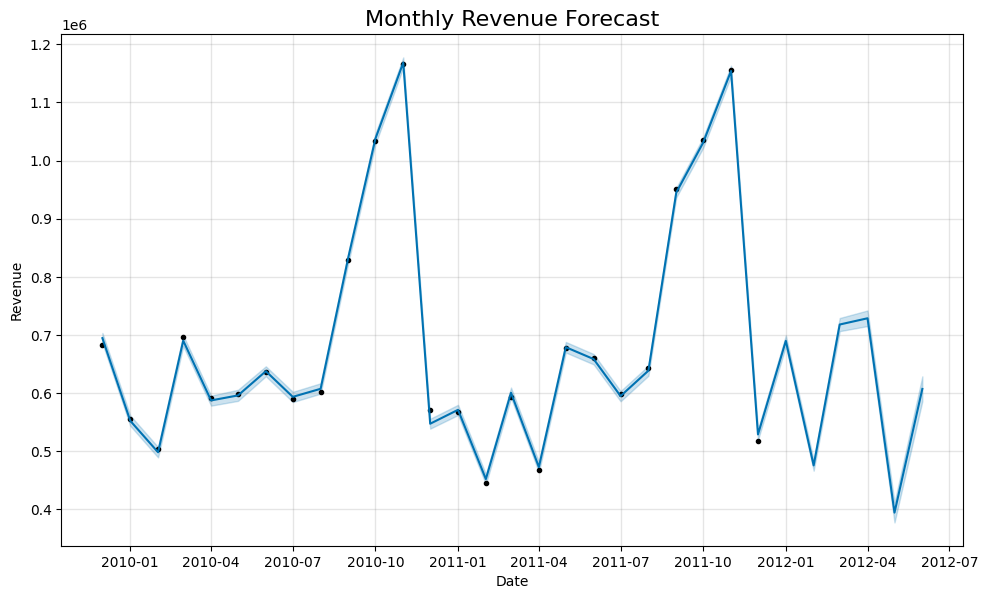

In [10]:
# ---------------------------------------
# Plot Actual vs Forecast
# ---------------------------------------

fig = model.plot(forecast)

plt.title("Monthly Revenue Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [11]:
# ---------------------------------------
# Save Forecast Chart
# ---------------------------------------

output_chart = "/content/drive/MyDrive/Retail Analytics System/screenshots/sales_forecast.png"

fig.savefig(output_chart, dpi=300, bbox_inches='tight')

print("Forecast chart saved successfully!")

Forecast chart saved successfully!


In [12]:
# ---------------------------------------
# Export Forecast Data
# ---------------------------------------

forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

output_path = "/content/drive/MyDrive/Retail Analytics System/data/cleaned/forecast.csv"

forecast_output.to_csv(output_path, index=False)

print("Forecast data exported successfully!")

Forecast data exported successfully!
